# Matchmaking: De Probabilidades a Decisiones

Notebook de soporte para la charla en UdeSA. Pipeline completo:
1. Generación de datos sintéticos
2. Estimación de probabilidades
3. Construcción del grafo de matching
4. Algoritmos de matching
5. Comparación de resultados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.special import expit  # sigmoide
from scipy.optimize import linear_sum_assignment, minimize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve
from matching.games import StableMarriage
from pathlib import Path
import time

np.random.seed(42)
IMG_DIR = Path("img")
IMG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
})

---
## Sección 1: Generación de datos sintéticos

200 usuarios con 6 dimensiones cada uno:
- belleza, poder adquisitivo, extroversión, intelectualidad, aventura, romanticismo

Cada usuario tiene:
- **Vector de características** (lo que "es"): con norma variable — algunos tienen "más de todo"
- **Vector de preferencias** (lo que busca): normalizado (dirección pura en el espacio de rasgos)

Existe un componente de **atractivo universal**: ciertos rasgos (belleza, poder adquisitivo) son valorados por casi todos, concentrando el deseo en un subconjunto de usuarios.

In [2]:
N_USERS = 1000
N_DIMS = 6
DIM_NAMES = ["belleza", "poder_adq", "extroversion", "intelectualidad", "aventura", "romanticismo"]

# Grupos: modelo heterosexual → grafo bipartito estricto
# Grupo A: usuarios 0..499  |  Grupo B: usuarios 500..999
group_a = list(range(0, N_USERS // 2))
group_b = list(range(N_USERS // 2, N_USERS))
group_a_set = set(group_a)
group_b_set = set(group_b)


def opposite_group(i):
    """Devuelve el grupo opuesto al usuario i."""
    return group_b if i in group_a_set else group_a


# --- Características (lo que cada usuario "es") ---
raw_feat = np.random.exponential(1, (N_USERS, N_DIMS))
feat_directions = raw_feat / np.linalg.norm(raw_feat, axis=1, keepdims=True)
feat_magnitudes = np.random.lognormal(mean=0.0, sigma=0.5, size=N_USERS)
features = feat_directions * feat_magnitudes[:, np.newaxis]

# --- Preferencias (lo que cada usuario busca) ---
universal_pref = np.array([0.45, 0.35, 0.05, 0.05, 0.05, 0.05])
universal_pref = universal_pref / np.linalg.norm(universal_pref)

personal_pref = np.abs(features + 0.5 * np.random.randn(N_USERS, N_DIMS))
alpha = np.random.beta(2, 3, N_USERS)
mixed = alpha[:, np.newaxis] * universal_pref + (1 - alpha[:, np.newaxis]) * personal_pref
preferences = mixed / np.linalg.norm(mixed, axis=1, keepdims=True)

print(f"Usuarios: {N_USERS}, Dimensiones: {N_DIMS}")
print(f"Grupo A: {len(group_a)} usuarios | Grupo B: {len(group_b)} usuarios")
print(f"Modelo: heterosexual → grafo bipartito (sin aristas intra-grupo)")
print(f"\nDistribución de norma de características:")
print(f"  Media: {np.linalg.norm(features, axis=1).mean():.2f}, "
      f"Std: {np.linalg.norm(features, axis=1).std():.2f}")

Usuarios: 1000, Dimensiones: 6
Grupo A: 500 usuarios | Grupo B: 500 usuarios
Modelo: heterosexual → grafo bipartito (sin aristas intra-grupo)

Distribución de norma de características:
  Media: 1.12, Std: 0.61


In [3]:
def p_directional(i, j):
    """P(i -> j): probabilidad de que i apruebe a j.

    Solo tiene sentido para pares cruzados (i en grupo A, j en grupo B o viceversa).
    """
    score = np.dot(preferences[i], features[j])
    return expit(2.5 * score - 2.5)


def p_mutual_true(i, j, correlation=0.15):
    """P(i <-> j): probabilidad mutua real (ground truth)."""
    p_ij = p_directional(i, j)
    p_ji = p_directional(j, i)
    product = p_ij * p_ji
    corr_term = correlation * min(p_ij, p_ji)
    return np.clip(product + corr_term, 0, 1)


# Calcular probabilidades solo para pares cruzados (grafo bipartito)
P_dir = np.zeros((N_USERS, N_USERS))
P_mut = np.zeros((N_USERS, N_USERS))

for i in group_a:
    for j in group_b:
        P_dir[i, j] = p_directional(i, j)
        P_dir[j, i] = p_directional(j, i)
        P_mut[i, j] = p_mutual_true(i, j)
        P_mut[j, i] = P_mut[i, j]

# Verificar: las probabilidades intra-grupo deben ser 0
assert P_dir[group_a[0], group_a[1]] == 0, "Error: arista intra-grupo detectada"

# Atractivo universal: correlación norma ↔ aprobaciones recibidas (solo del grupo opuesto)
feat_norms = np.linalg.norm(features, axis=1)
avg_p_received_a = P_dir[group_b, :][:, group_a].mean(axis=0)  # recibe grupo A
avg_p_received_b = P_dir[group_a, :][:, group_b].mean(axis=0)  # recibe grupo B
avg_p_received = np.concatenate([avg_p_received_a, avg_p_received_b])
corr_norm_attractiveness = np.corrcoef(feat_norms, avg_p_received)[0, 1]

print(f"P direccional — media: {P_dir[P_dir > 0].mean():.3f}, std: {P_dir[P_dir > 0].std():.3f}")
print(f"P mutua real  — media: {P_mut[P_mut > 0].mean():.3f}, std: {P_mut[P_mut > 0].std():.3f}")
print(f"\nCorrelación norma ↔ atractivo recibido: {corr_norm_attractiveness:.3f}")

P direccional — media: 0.351, std: 0.205
P mutua real  — media: 0.160, std: 0.129

Correlación norma ↔ atractivo recibido: 0.922


In [4]:
# Generar observaciones históricas (accept/reject)
# En dating heterosexual, cada usuario ve candidatos del grupo opuesto
N_SHOWN = 20
observations = []

for i in range(N_USERS):
    candidates = np.random.choice(opposite_group(i), size=N_SHOWN, replace=False)
    for j in candidates:
        p = p_directional(i, j)
        accepted = np.random.rand() < p
        observations.append({
            "user_i": i,
            "user_j": j,
            "accepted": int(accepted),
            "p_true": p,
        })

df_obs = pd.DataFrame(observations)
print(f"Observaciones generadas: {len(df_obs)}")
print(f"Tasa de aceptación: {df_obs['accepted'].mean():.1%}")
print(f"Pares únicos observados (siempre cruzados): {df_obs[['user_i','user_j']].nunique().sum()}")
df_obs.head()

Observaciones generadas: 20000
Tasa de aceptación: 35.1%
Pares únicos observados (siempre cruzados): 2000


,user_i,user_j,accepted,p_true
0,0,700,1,0.236516
1,0,789,1,0.217856
2,0,808,1,0.478628
3,0,788,0,0.219798
4,0,694,1,0.777355


---
## 🎯 PAUSA CHARLA
Volver a slides para explicar el problema conceptualmente (probabilidades direccionales vs. mutuas, el dilema de Brad Pitt / Penélope Cruz).

---
## Sección 2: Estimación de probabilidades

Dos modelos:
1. **Logistic Regression**: interpretable
2. **Gradient Boosted Trees**: más preciso, menos interpretable

In [5]:
# Features para los modelos: interacción pref×feat, producto punto, norma, coseno

def build_pair_features(user_i, user_j):
    """Features para predecir si user_i aprueba a user_j."""
    interaction = preferences[user_i] * features[user_j]
    dot_prod = np.dot(preferences[user_i], features[user_j])
    feat_norm = np.linalg.norm(features[user_j])
    cos_sim = dot_prod / (feat_norm + 1e-8)
    return np.concatenate([interaction, [dot_prod, feat_norm, cos_sim]])


X = np.array([build_pair_features(int(row.user_i), int(row.user_j)) for _, row in df_obs.iterrows()])
y = df_obs["accepted"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Features por par: {X.shape[1]} (6 interacción + dot_prod + norma + cos_sim)")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Features por par: 9 (6 interacción + dot_prod + norma + cos_sim)
Train: 14000, Test: 6000


In [6]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Gradient Boosted Trees
gbt = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gbt.fit(X_train, y_train)
y_prob_gbt = gbt.predict_proba(X_test)[:, 1]
auc_gbt = roc_auc_score(y_test, y_prob_gbt)

print(f"AUC Logistic Regression: {auc_lr:.3f}")
print(f"AUC Gradient Boosted Trees: {auc_gbt:.3f}")

AUC Logistic Regression: 0.727
AUC Gradient Boosted Trees: 0.725


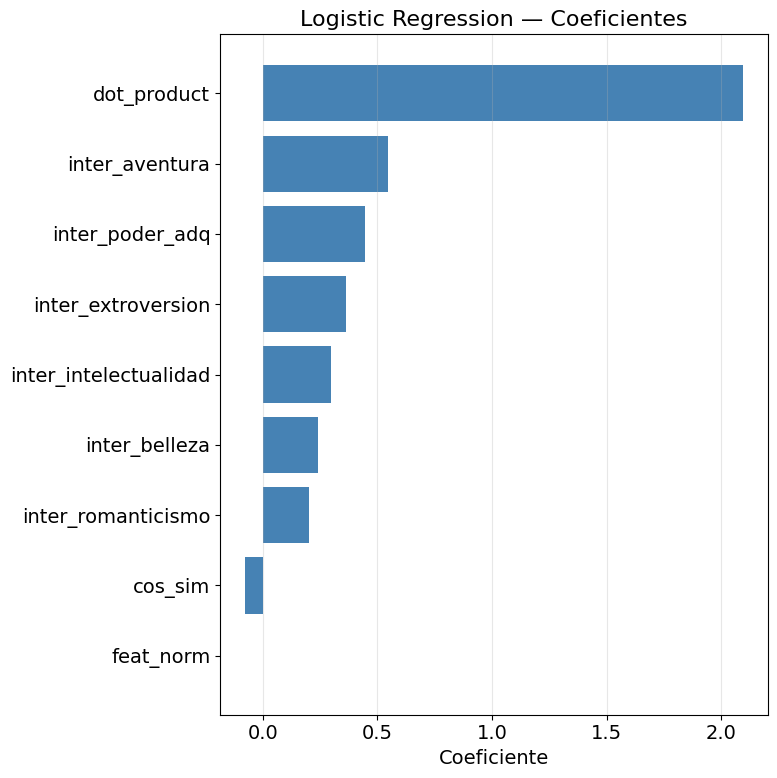

In [7]:
# Coeficientes del modelo logístico (interpretabilidad)
feature_names = (
    [f"inter_{d}" for d in DIM_NAMES]
    + ["dot_product", "feat_norm", "cos_sim"]
)
coef_df = pd.DataFrame({"feature": feature_names, "coef": lr.coef_[0]})
coef_df = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(coef_df["feature"], coef_df["coef"], color="steelblue")
ax.set_xlabel("Coeficiente")
ax.set_title("Logistic Regression — Coeficientes")
ax.grid(True, alpha=0.3, axis="x")
fig.tight_layout()
plt.show()

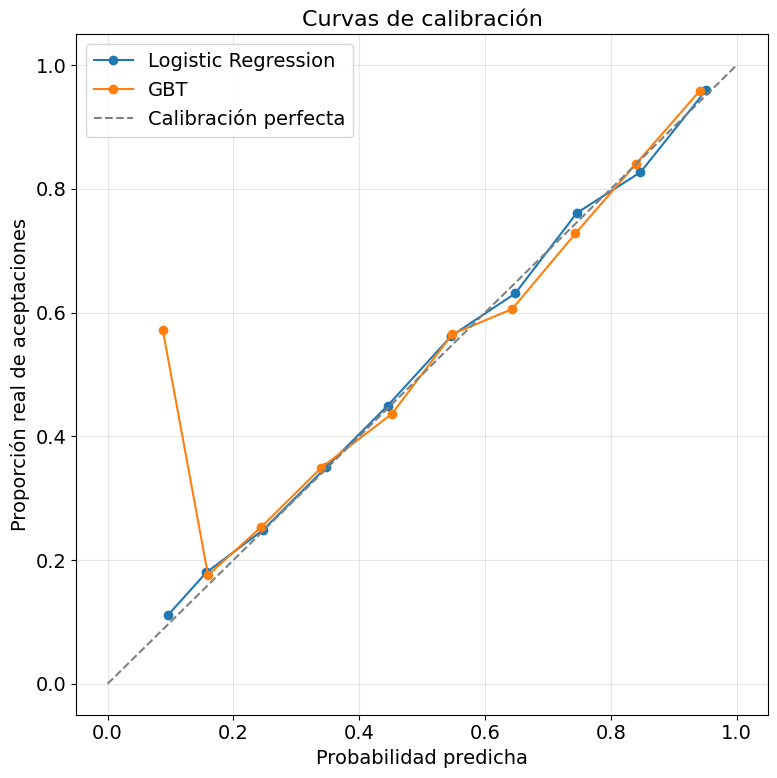

In [8]:
# Curvas de calibración
fig, ax = plt.subplots(figsize=(8, 8))

for name, y_prob in [("Logistic Regression", y_prob_lr), ("GBT", y_prob_gbt)]:
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    ax.plot(prob_pred, prob_true, "o-", label=name)

ax.plot([0, 1], [0, 1], "--", color="gray", label="Calibración perfecta")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Proporción real de aceptaciones")
ax.set_title("Curvas de calibración")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

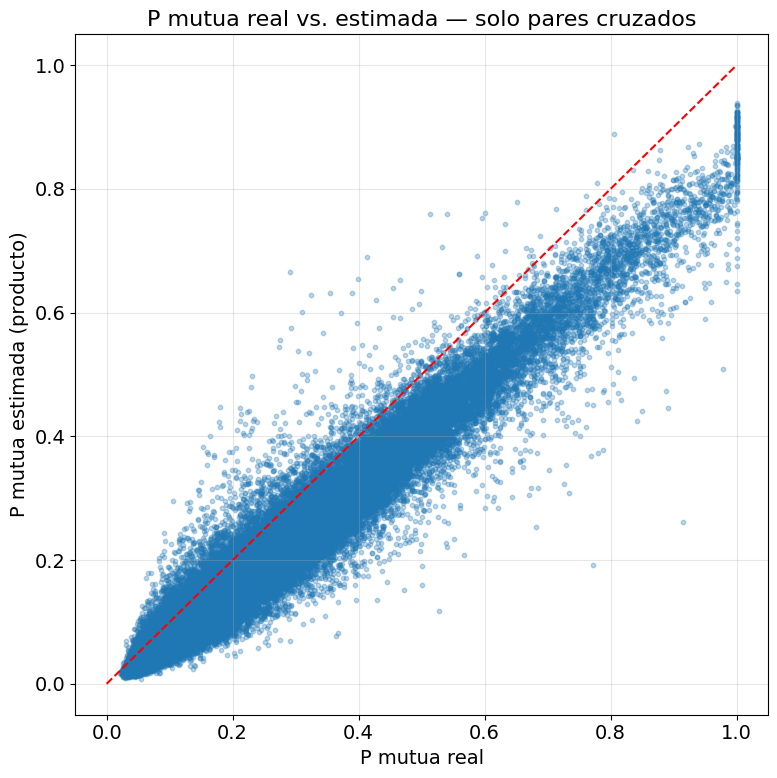

Correlación: 0.980
Sesgo medio (est - real): -0.0386


In [9]:
# Estimar P_mutua: producto de direccionales vs. realidad
# Solo estimamos pares cruzados (grafo bipartito)

def estimate_all_directional(model):
    """Estimar P(i -> j) para todos los pares cruzados, vectorizado."""
    pairs = []
    indices = []
    for i in group_a:
        for j in group_b:
            pairs.append(build_pair_features(i, j))
            indices.append((i, j))
        # También j->i
    for j in group_b:
        for i in group_a:
            pairs.append(build_pair_features(j, i))
            indices.append((j, i))

    X_all = np.array(pairs)
    probs = model.predict_proba(X_all)[:, 1]

    P_est = np.zeros((N_USERS, N_USERS))
    for (i, j), p in zip(indices, probs):
        P_est[i, j] = p
    return P_est


P_dir_est = estimate_all_directional(gbt)

# Estimar P_mutua como producto de direccionales (solo pares cruzados)
P_mut_est = np.zeros((N_USERS, N_USERS))
for i in group_a:
    for j in group_b:
        P_mut_est[i, j] = P_dir_est[i, j] * P_dir_est[j, i]
        P_mut_est[j, i] = P_mut_est[i, j]

# Verificar estructura bipartita
assert P_mut_est[group_a[0], group_a[1]] == 0, "Error: probabilidad intra-grupo no nula"

# Comparar con ground truth (solo pares cruzados)
cross_i = [i for i in group_a for j in group_b]
cross_j = [j for i in group_a for j in group_b]
p_mut_real = np.array([P_mut[i, j] for i, j in zip(cross_i, cross_j)])
p_mut_pred = np.array([P_mut_est[i, j] for i, j in zip(cross_i, cross_j)])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(p_mut_real, p_mut_pred, alpha=0.3, s=10)
ax.plot([0, 1], [0, 1], "--", color="red")
ax.set_xlabel("P mutua real")
ax.set_ylabel("P mutua estimada (producto)")
ax.set_title("P mutua real vs. estimada — solo pares cruzados")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

corr = np.corrcoef(p_mut_real, p_mut_pred)[0, 1]
print(f"Correlación: {corr:.3f}")
print(f"Sesgo medio (est - real): {(p_mut_pred - p_mut_real).mean():.4f}")

---
## Sección 3: Grafo de matching

Construimos el grafo completo ponderado de los 200 usuarios.
Peso de cada arista = P_mutua estimada.

In [10]:
# Construir grafo
G = nx.Graph()
G.add_nodes_from(range(N_USERS))

for i in range(N_USERS):
    for j in range(i+1, N_USERS):
        if P_mut_est[i, j] > 0.01:  # filtrar aristas muy débiles para visualización
            G.add_edge(i, j, weight=P_mut_est[i, j])

print(f"Nodos: {G.number_of_nodes()}")
print(f"Aristas (peso > 0.01): {G.number_of_edges()}")

Nodos: 1000
Aristas (peso > 0.01): 249997


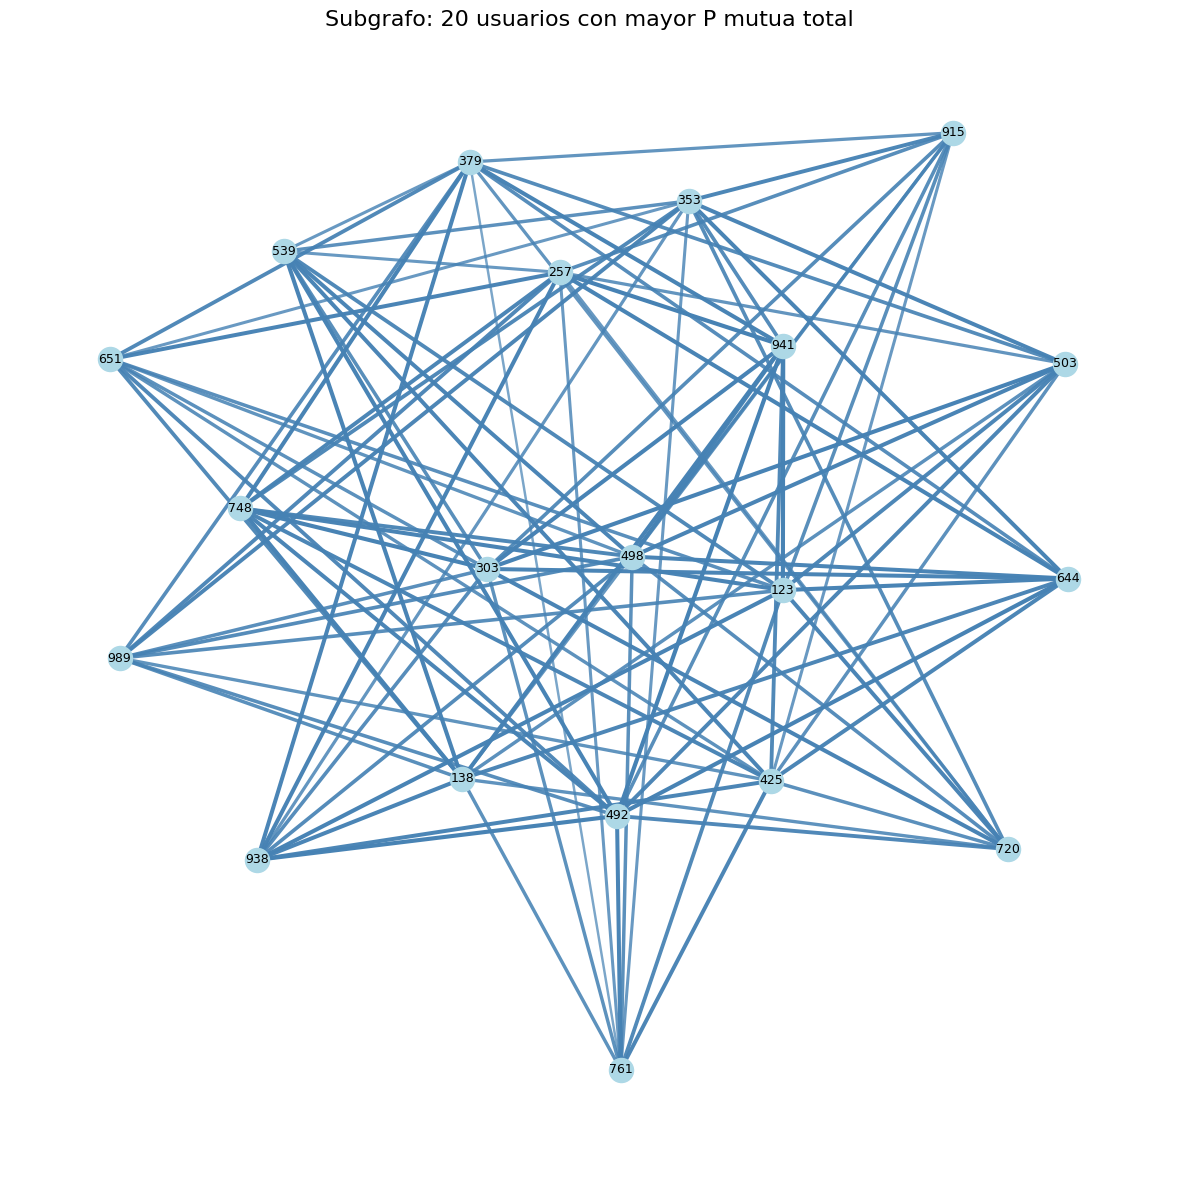

In [11]:
# Visualización de subgrafo (~20 nodos con mejores probabilidades mutuas)
# Elegimos los 20 nodos con mayor suma de P_mutua
node_strength = P_mut_est.sum(axis=1)
top_nodes = np.argsort(node_strength)[-20:]

G_sub = G.subgraph(top_nodes).copy()
weights = [G_sub[u][v]["weight"] for u, v in G_sub.edges()]
max_w = max(weights) if weights else 1

fig, ax = plt.subplots(figsize=(12, 12))
pos = nx.spring_layout(G_sub, seed=42, k=2)
nx.draw_networkx_nodes(G_sub, pos, node_size=300, node_color="lightblue", ax=ax)
nx.draw_networkx_labels(G_sub, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(
    G_sub, pos,
    width=[3 * w / max_w for w in weights],
    alpha=[0.3 + 0.7 * w / max_w for w in weights],
    edge_color="steelblue",
    ax=ax,
)
ax.set_title("Subgrafo: 20 usuarios con mayor P mutua total")
ax.axis("off")
fig.tight_layout()
plt.show()

---
## 🎯 PAUSA CHARLA
Volver a slides para explicar los algoritmos de matching antes de correrlos (Gale-Shapley, max weight, fuerza bruta).

---
## Sección 4: Algoritmos de matching

### 4a. Gale-Shapley (Stable Matching)

Rankings derivados de las probabilidades direccionales estimadas.
Garantiza estabilidad, no bienestar global.

In [12]:
# Grupos ya definidos en la sección 1 (group_a, group_b)
# Construir rankings usando P_dir_est (ya calculada vectorizadamente)
prefs_a = {}
for i in group_a:
    scores = [(j, P_dir_est[i, j]) for j in group_b]
    scores.sort(key=lambda x: -x[1])
    prefs_a[i] = [j for j, _ in scores]

prefs_b = {}
for j in group_b:
    scores = [(i, P_dir_est[j, i]) for i in group_a]
    scores.sort(key=lambda x: -x[1])
    prefs_b[j] = [i for i, _ in scores]

print(f"Grupo A: {len(group_a)} usuarios, Grupo B: {len(group_b)} usuarios")
print(f"Ejemplo ranking de usuario 0: {prefs_a[0][:5]}... (top 5)")

Grupo A: 500 usuarios, Grupo B: 500 usuarios


Ejemplo ranking de usuario 0: [941, 803, 748, 720, 637]... (top 5)


In [13]:
# Implementación propia de Gale-Shapley
def gale_shapley(prefs_proposers, prefs_reviewers):
    """Gale-Shapley con el primer grupo como proponentes."""
    free = list(prefs_proposers.keys())
    proposals = {p: 0 for p in free}  # índice del próximo a proponer
    matches = {}  # reviewer -> proposer
    
    # Pre-computar ranking inverso para reviewers
    rank = {}
    for r, pref_list in prefs_reviewers.items():
        rank[r] = {p: i for i, p in enumerate(pref_list)}
    
    while free:
        p = free.pop(0)
        r = prefs_proposers[p][proposals[p]]
        proposals[p] += 1
        
        if r not in matches:
            matches[r] = p
        elif rank[r][p] < rank[r][matches[r]]:
            # r prefiere a p sobre su match actual
            free.append(matches[r])
            matches[r] = p
        else:
            free.append(p)
    
    return {v: k for k, v in matches.items()}  # proposer -> reviewer


t0 = time.time()
gs_matching = gale_shapley(prefs_a, prefs_b)
t_gs = time.time() - t0

# Peso total del matching GS
gs_weight = sum(P_mut_est[i, j] for i, j in gs_matching.items())
print(f"Gale-Shapley: {len(gs_matching)} pares, peso total = {gs_weight:.3f}, tiempo = {t_gs:.4f}s")

Gale-Shapley: 500 pares, peso total = 137.768, tiempo = 0.0199s


In [14]:
# Verificación con librería `matching` (aumentamos límite de recursión para N=500)
import sys
sys.setrecursionlimit(10000)
game = StableMarriage.create_from_dictionaries(prefs_a, prefs_b)
lib_result = game.solve()
gs_matching_lib = {p.name: r.name for p, r in lib_result.items()}
sys.setrecursionlimit(1000)  # restaurar

# Comparar
gs_weight_lib = sum(P_mut_est[i, j] for i, j in gs_matching_lib.items())
print(f"Librería matching: {len(gs_matching_lib)} pares, peso total = {gs_weight_lib:.3f}")
print(f"Implementación propia y librería coinciden: {gs_matching == gs_matching_lib}")

Librería matching: 500 pares, peso total = 137.768
Implementación propia y librería coinciden: True


### 4b. Maximum Weight Matching

Usando `networkx.max_weight_matching` y alternativamente `scipy.optimize.linear_sum_assignment`.

In [15]:
# Max weight matching sobre el grafo BIPARTITO completo
# Solo aristas cruzadas (grupo A ↔ grupo B)
G_full = nx.Graph()
G_full.add_nodes_from(range(N_USERS))
for i in group_a:
    for j in group_b:
        G_full.add_edge(i, j, weight=P_mut_est[i, j])

t0 = time.time()
mwm_matching = nx.max_weight_matching(G_full, maxcardinality=True)
t_mwm = time.time() - t0

mwm_weight = sum(P_mut_est[i, j] for i, j in mwm_matching)
print(f"Max Weight Matching (bipartito): {len(mwm_matching)} pares, peso total = {mwm_weight:.3f}, tiempo = {t_mwm:.4f}s")
# Nota: sobre grafo bipartito, max weight matching = linear_sum_assignment (ambos óptimos)

Max Weight Matching (bipartito): 500 pares, peso total = 151.126, tiempo = 106.7129s


In [16]:
# Alternativa: scipy linear_sum_assignment (formulación como problema de asignación)
# Nota: solo funciona para matching bipartito, lo usamos sobre los mismos grupos
cost_matrix = np.zeros((len(group_a), len(group_b)))
for ii, i in enumerate(group_a):
    for jj, j in enumerate(group_b):
        cost_matrix[ii, jj] = -P_mut_est[i, j]  # negativo porque minimiza

t0 = time.time()
row_ind, col_ind = linear_sum_assignment(cost_matrix)
t_scipy = time.time() - t0

scipy_matching = {group_a[ii]: group_b[jj] for ii, jj in zip(row_ind, col_ind)}
scipy_weight = sum(P_mut_est[i, j] for i, j in scipy_matching.items())
print(f"Scipy (bipartito): {len(scipy_matching)} pares, peso total = {scipy_weight:.3f}, tiempo = {t_scipy:.4f}s")

Scipy (bipartito): 500 pares, peso total = 151.126, tiempo = 0.0127s


### 4c. Greedy Matching

Algoritmo voraz: ordenar aristas por peso descendente y agregar si ambos nodos están libres.
Garantiza una 1/2-aproximación al óptimo. Simple, rápido, intuitivo.

In [17]:
# Greedy matching: agregar aristas de mayor a menor peso
def greedy_matching(P_matrix, ga, gb):
    """Matching greedy bipartito: solo considera aristas cruzadas entre ga y gb."""
    edges = [(P_matrix[i, j], i, j) for i in ga for j in gb]
    edges.sort(reverse=True)

    matched = set()
    matching = set()
    for w, i, j in edges:
        if i not in matched and j not in matched:
            matching.add((i, j))
            matched.add(i)
            matched.add(j)
    return matching


t0 = time.time()
greedy_match = greedy_matching(P_mut_est, group_a, group_b)
t_greedy = time.time() - t0

greedy_weight = sum(P_mut_est[i, j] for i, j in greedy_match)
print(f"Greedy Matching (bipartito): {len(greedy_match)} pares, peso total = {greedy_weight:.3f}, tiempo = {t_greedy:.4f}s")

Greedy Matching (bipartito): 500 pares, peso total = 142.931, tiempo = 0.1481s


### 4d. Fuerza bruta con scipy.minimize

Formulación como optimización continua relajada con límite de iteraciones.
Para que sea tratable, lo hacemos sobre un **subconjunto pequeño** (10 usuarios).

In [18]:
# Fuerza bruta: relajación continua sobre un subconjunto de 30 usuarios (15x15)
# Demostración del concepto — no escala a N_USERS completo
N_BF = 20  # usuarios por lado

bf_group_a = group_a[:N_BF]
bf_group_b = group_b[:N_BF]
P_matrix_bf = np.array([[P_mut_est[i, j] for j in bf_group_b] for i in bf_group_a])


def objective(x):
    return -np.sum(x.reshape(N_BF, N_BF) * P_matrix_bf)


constraints = []
for i in range(N_BF):
    constraints.append({"type": "ineq", "fun": lambda x, i=i: 1 - x.reshape(N_BF, N_BF)[i, :].sum()})
for j in range(N_BF):
    constraints.append({"type": "ineq", "fun": lambda x, j=j: 1 - x.reshape(N_BF, N_BF)[:, j].sum()})

bounds = [(0, 1)] * (N_BF * N_BF)
x0 = np.full(N_BF * N_BF, 1.0 / N_BF)

t0 = time.time()
result = minimize(objective, x0, method="SLSQP", bounds=bounds, constraints=constraints,
                  options={"maxiter": 1000, "ftol": 1e-9})
t_brute = time.time() - t0

X_opt = result.x.reshape(N_BF, N_BF)
bf_matching = {}
used_b = set()
for ii in np.argsort(-X_opt.max(axis=1)):
    for jj in np.argsort(-X_opt[ii]):
        if jj not in used_b:
            bf_matching[bf_group_a[ii]] = bf_group_b[jj]
            used_b.add(jj)
            break

bf_weight = sum(P_mut_est[i, j] for i, j in bf_matching.items())

# Óptimo del mismo subconjunto (referencia)
cost_bf = np.array([[-P_mut_est[i, j] for j in bf_group_b] for i in bf_group_a])
row_bf, col_bf = linear_sum_assignment(cost_bf)
opt_bf_weight = sum(P_mut_est[bf_group_a[ii], bf_group_b[jj]] for ii, jj in zip(row_bf, col_bf))

print(f"Subconjunto: {N_BF}x{N_BF} usuarios")
print(f"Fuerza bruta (SLSQP): peso = {bf_weight:.4f}, tiempo = {t_brute:.2f}s")
print(f"Óptimo (linear_sum):  peso = {opt_bf_weight:.4f}")
print(f"Gap: {(1 - bf_weight / opt_bf_weight) * 100:.1f}%")
print(f"Convergió: {result.success}, iteraciones: {result.nit}")

Subconjunto: 20x20 usuarios
Fuerza bruta (SLSQP): peso = 4.6873, tiempo = 7.29s
Óptimo (linear_sum):  peso = 4.6873
Gap: -0.0%
Convergió: True, iteraciones: 51


---
## Sección 5: Comparación de resultados

### 5a. Comparación principal (500 usuarios — sin fuerza bruta)

### 5b. Comparación completa con 30 usuarios (incluye fuerza bruta)

In [19]:
# Comparación completa: todos los algoritmos sobre 20 usuarios
N_SMALL = N_BF * 2  # = 40

# 1. Gale-Shapley
prefs_a_s = {}
for i in bf_group_a:
    scores = [(j, P_dir_est[i, j]) for j in bf_group_b]
    scores.sort(key=lambda x: -x[1])
    prefs_a_s[i] = [j for j, _ in scores]
prefs_b_s = {}
for j in bf_group_b:
    scores = [(i, P_dir_est[j, i]) for i in bf_group_a]
    scores.sort(key=lambda x: -x[1])
    prefs_b_s[j] = [i for i, _ in scores]

t0 = time.time()
gs_s = gale_shapley(prefs_a_s, prefs_b_s)
t_gs_s = time.time() - t0
gs_s_weight = sum(P_mut_est[i, j] for i, j in gs_s.items())

# 2. Greedy (bipartito)
t0 = time.time()
greedy_s = greedy_matching(P_mut_est, bf_group_a, bf_group_b)
t_greedy_s = time.time() - t0
greedy_s_weight = sum(P_mut_est[i, j] for i, j in greedy_s)

# 3. Max Weight (bipartito)
G_small = nx.Graph()
G_small.add_nodes_from(bf_group_a + bf_group_b)
for i in bf_group_a:
    for j in bf_group_b:
        G_small.add_edge(i, j, weight=P_mut_est[i, j])
t0 = time.time()
mwm_s = nx.max_weight_matching(G_small, maxcardinality=True)
t_mwm_s = time.time() - t0
mwm_s_weight = sum(P_mut_est[i, j] for i, j in mwm_s)

# 4. Scipy bipartito
cost_s = np.array([[-P_mut_est[i, j] for j in bf_group_b] for i in bf_group_a])
t0 = time.time()
row_s, col_s = linear_sum_assignment(cost_s)
t_scipy_s = time.time() - t0
scipy_s = {bf_group_a[ii]: bf_group_b[jj] for ii, jj in zip(row_s, col_s)}
scipy_s_weight = sum(P_mut_est[i, j] for i, j in scipy_s.items())

# 5. Fuerza bruta (ya calculada)
ref_weight = scipy_s_weight

results_small = pd.DataFrame({
    "Algoritmo": ["Gale-Shapley", "Greedy", "Max Weight", "Scipy bipartito", "Fuerza bruta"],
    "Pares": [len(gs_s), len(greedy_s), len(mwm_s), len(scipy_s), len(bf_matching)],
    "Peso total": [gs_s_weight, greedy_s_weight, mwm_s_weight, scipy_s_weight, bf_weight],
    "Tiempo (s)": [t_gs_s, t_greedy_s, t_mwm_s, t_scipy_s, t_brute],
})
results_small["% del óptimo (bipartito)"] = (results_small["Peso total"] / ref_weight * 100).round(1)

print(f"Comparación sobre {N_SMALL} usuarios (grafo bipartito estricto):")
print(f"Nota: Max Weight y Scipy deben coincidir (ambos óptimos para bipartito)")
results_small

Comparación sobre 40 usuarios (grafo bipartito estricto):
Nota: Max Weight y Scipy deben coincidir (ambos óptimos para bipartito)


,Algoritmo,Pares,Peso total,Tiempo (s),% del óptimo (bipartito)
0,Gale-Shapley,20,4.431992,0.000065,94.6
1,Greedy,20,4.485155,0.000165,95.7
2,Max Weight,20,4.687255,0.006390,100.0
3,Scipy bipartito,20,4.687255,0.000046,100.0
4,Fuerza bruta,20,4.687255,7.290209,100.0


In [20]:
# Mostrar tabla comparativa (30 usuarios) — datos para la slide Typst
results_small_fmt = results_small.copy()
results_small_fmt["Peso total"] = results_small_fmt["Peso total"].round(3)
results_small_fmt["% del óptimo (bipartito)"] = results_small_fmt["% del óptimo (bipartito)"].round(1)
results_small_fmt["Tiempo (s)"] = results_small_fmt["Tiempo (s)"].apply(
    lambda x: f"{x:.4f}" if x >= 0.0001 else f"{x:.2e}"
)
print("=== TABLA SMALL (para slides.typ) ===")
print(results_small_fmt.to_string(index=False))
results_small_fmt

=== TABLA SMALL (para slides.typ) ===
      Algoritmo  Pares  Peso total Tiempo (s)  % del óptimo (bipartito)
   Gale-Shapley     20       4.432   6.48e-05                      94.6
         Greedy     20       4.485     0.0002                      95.7
     Max Weight     20       4.687     0.0064                     100.0
Scipy bipartito     20       4.687   4.58e-05                     100.0
   Fuerza bruta     20       4.687     7.2902                     100.0


,Algoritmo,Pares,Peso total,Tiempo (s),% del óptimo (bipartito)
0,Gale-Shapley,20,4.432,6.48e-05,94.6
1,Greedy,20,4.485,0.0002,95.7
2,Max Weight,20,4.687,0.0064,100.0
3,Scipy bipartito,20,4.687,4.58e-05,100.0
4,Fuerza bruta,20,4.687,7.2902,100.0


In [21]:
# Tabla comparativa: 4 algoritmos sobre 200 usuarios
results = pd.DataFrame({
    "Algoritmo": ["Gale-Shapley", "Greedy", "Max Weight (networkx)", "Scipy bipartito"],
    "Pares": [len(gs_matching), len(greedy_match), len(mwm_matching), len(scipy_matching)],
    "Peso total": [gs_weight, greedy_weight, mwm_weight, scipy_weight],
    "Tiempo (s)": [t_gs, t_greedy, t_mwm, t_scipy],
})
results["% del óptimo (bipartito)"] = (results["Peso total"] / scipy_weight * 100).round(1)
print("Comparación sobre 500 usuarios:")
results

Comparación sobre 500 usuarios:


,Algoritmo,Pares,Peso total,Tiempo (s),% del óptimo (bipartito)
0,Gale-Shapley,500,137.767729,0.019865,91.2
1,Greedy,500,142.930756,0.148117,94.6
2,Max Weight (networkx),500,151.126464,106.712915,100.0
3,Scipy bipartito,500,151.126464,0.012681,100.0


In [22]:
# Matchings: 3 SVGs con layout idéntico — solo cambian las aristas entre slides
# Layout: Grupo A arriba, Grupo B abajo — formato apaisado 16:9

pos_bf = {}
for k, i in enumerate(sorted(bf_group_a)):
    pos_bf[i] = (float(k), 1.0)   # fila superior
for k, j in enumerate(sorted(bf_group_b)):
    pos_bf[j] = (float(k), 0.0)   # fila inferior

labels_bf = {i: str(i - bf_group_a[0]) for i in bf_group_a}
labels_bf.update({j: str(j - bf_group_b[0]) for j in bf_group_b})

# Mejor par estimado y real dentro del subgrupo
P_sub_est  = np.array([[P_mut_est[i, j] for j in bf_group_b] for i in bf_group_a])
P_sub_real = np.array([[P_mut[i, j]     for j in bf_group_b] for i in bf_group_a])
r_e, c_e = np.unravel_index(P_sub_est.argmax(),  P_sub_est.shape)
r_r, c_r = np.unravel_index(P_sub_real.argmax(), P_sub_real.shape)
best_est  = (bf_group_a[r_e], bf_group_b[c_e])
best_real = (bf_group_a[r_r], bf_group_b[c_r])
print(f"Mayor P estimada: {best_est}  = {P_sub_est.max():.3f}")
print(f"Mayor P real:     {best_real} = {P_sub_real.max():.3f}")
same_pair = (best_est == best_real)

def norm_pairs(m, ga_set):
    pairs = list(m.items()) if isinstance(m, dict) else list(m)
    return [(a, b) if a in ga_set else (b, a) for a, b in pairs]

ga_set = set(bf_group_a)
algo_matchings = [
    ("Gale-Shapley", norm_pairs(gs_s,     ga_set), "matching_gs.svg"),
    ("Greedy",       norm_pairs(greedy_s,  ga_set), "matching_greedy.svg"),
    ("Max Weight",   norm_pairs(mwm_s,    ga_set),  "matching_mwm.svg"),
]

# Grafo solo con nodos
G_bf = nx.Graph()
G_bf.add_nodes_from(bf_group_a)
G_bf.add_nodes_from(bf_group_b)
node_colors = ["#2196F3" if n in ga_set else "#F44336" for n in G_bf.nodes()]

# Parámetros idénticos para los 3 SVGs — landscape 16:9, Grupo A arriba
FIGSIZE  = (16, 9)
XLIM     = (-0.7, N_BF - 0.3)
YLIM     = (-0.4, 1.4)
MARGINS  = dict(left=0.01, right=0.99, top=0.95, bottom=0.08)
mid_x    = (N_BF - 1) / 2.0

for algo_name, pairs, filename in algo_matchings:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    fig.subplots_adjust(**MARGINS)
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)

    # Nodos
    nx.draw_networkx_nodes(G_bf, pos_bf, node_color=node_colors,
                           node_size=420, ax=ax)
    nx.draw_networkx_labels(G_bf, pos_bf, labels=labels_bf,
                            font_size=8, font_color="white", ax=ax)

    # Etiquetas de grupo (arriba y abajo)
    ax.text(mid_x,  1.30, "Grupo A", fontsize=12, color="#2196F3",
            ha="center", va="center", fontweight="bold")
    ax.text(mid_x, -0.23, "Grupo B", fontsize=12, color="#F44336",
            ha="center", va="center", fontweight="bold")

    # Aristas del matching (gris neutro)
    for i, j in pairs:
        ax.plot([pos_bf[i][0], pos_bf[j][0]],
                [pos_bf[i][1], pos_bf[j][1]],
                color="#9E9E9E", linewidth=2.2, alpha=0.9,
                solid_capstyle="round")

    # Mayor P estimada — naranja brillante, raya larga
    e0, e1 = best_est
    ax.plot([pos_bf[e0][0], pos_bf[e1][0]],
            [pos_bf[e0][1], pos_bf[e1][1]],
            linestyle=(0, (7, 4)), color="#FF6D00", linewidth=3.5,
            label=f"Mayor $P$ est. = {P_sub_est.max():.2f}")

    # Mayor P real — naranja oscuro, punteado fino (solo si es distinto)
    if not same_pair:
        r0, r1 = best_real
        ax.plot([pos_bf[r0][0], pos_bf[r1][0]],
                [pos_bf[r0][1], pos_bf[r1][1]],
                linestyle=(0, (2, 3)), color="#BF360C", linewidth=3.0,
                label=f"Mayor $P$ real = {P_sub_real.max():.2f}")
    else:
        ax.plot([], [], linestyle=(0, (2, 3)), color="#BF360C", linewidth=3.0,
                label=f"(misma arista, $P$ real = {P_sub_real.max():.2f})")

    weight = sum(P_mut_est[i, j] for i, j in pairs)
    ax.set_title(f"{algo_name} — peso estimado total: {weight:.3f}",
                 fontsize=13, pad=5)
    ax.legend(fontsize=10, loc="lower center",
              framealpha=0.9, edgecolor="#CCCCCC")
    ax.axis("off")

    fig.savefig(IMG_DIR / filename)   # sin bbox_inches para tamaño idéntico
    plt.close(fig)
    print(f"Guardado: img/{filename}")

Mayor P estimada: (12, 503)  = 0.809
Mayor P real:     (12, 503) = 0.971
Guardado: img/matching_gs.svg
Guardado: img/matching_greedy.svg
Guardado: img/matching_mwm.svg


In [23]:
# Insight: ¿el par con mayor P mutua estimada está en el matching global?
best_i, best_j = np.unravel_index(np.argmax(P_mut_est), P_mut_est.shape)
best_p = P_mut_est[best_i, best_j]
print(f"Par con mayor P mutua estimada: ({best_i}, {best_j}) = {best_p:.4f}")
print()

# Matchings del problema completo (500 usuarios)
matchings = {
    "Gale-Shapley":    set((min(i,j), max(i,j)) for i, j in gs_matching.items()),
    "Greedy":          set((min(i,j), max(i,j)) for i, j in greedy_match),
    "Max Weight":      set((min(i,j), max(i,j)) for i, j in mwm_matching),
    "Scipy bipartito": set((min(i,j), max(i,j)) for i, j in scipy_matching.items()),
}

pair = (min(best_i, best_j), max(best_i, best_j))
for name, match_set in matchings.items():
    present = pair in match_set
    print(f"  {name}: {'✓ incluido' if present else '✗ NO incluido'}")

Par con mayor P mutua estimada: (265, 503) = 0.9397

  Gale-Shapley: ✓ incluido
  Greedy: ✓ incluido
  Max Weight: ✗ NO incluido
  Scipy bipartito: ✗ NO incluido


---
## Sección 6: Predicciones vs. Realidad

¿Qué pasa si corremos cada algoritmo sobre la P mutua *real* (ground truth)?
Comparamos el peso total según predicciones vs. según valores reales
para detectar brechas sistemáticas.

In [24]:
# --- Correr los mismos algoritmos sobre P_mut (ground truth) ---

# 1. Gale-Shapley sobre ground truth
prefs_a_real = {}
for i in group_a:
    scores = [(j, P_dir[i, j]) for j in group_b]
    scores.sort(key=lambda x: -x[1])
    prefs_a_real[i] = [j for j, _ in scores]
prefs_b_real = {}
for j in group_b:
    scores = [(i, P_dir[j, i]) for i in group_a]
    scores.sort(key=lambda x: -x[1])
    prefs_b_real[j] = [i for i, _ in scores]
gs_matching_real = gale_shapley(prefs_a_real, prefs_b_real)

# 2. Greedy sobre ground truth (bipartito)
greedy_match_real = greedy_matching(P_mut, group_a, group_b)

# 3. Max weight matching sobre ground truth (bipartito)
G_full_real = nx.Graph()
G_full_real.add_nodes_from(range(N_USERS))
for i in group_a:
    for j in group_b:
        G_full_real.add_edge(i, j, weight=P_mut[i, j])
mwm_matching_real = nx.max_weight_matching(G_full_real, maxcardinality=True)

# 4. Scipy bipartito sobre ground truth
cost_matrix_real = np.array([[-P_mut[i, j] for j in group_b] for i in group_a])
row_ind_r, col_ind_r = linear_sum_assignment(cost_matrix_real)
scipy_matching_real = {group_a[ii]: group_b[jj] for ii, jj in zip(row_ind_r, col_ind_r)}

# --- Evaluar cada matching con ambas métricas ---
def eval_matching(matching, P_est, P_real):
    if isinstance(matching, dict):
        pairs = list(matching.items())
    else:
        pairs = list(matching)
    w_est = sum(P_est[i, j] for i, j in pairs)
    w_real = sum(P_real[i, j] for i, j in pairs)
    return w_est, w_real

algo_names = ["Gale-Shapley", "Greedy", "Max Weight", "Scipy bipartito"]
matchings_pred = [gs_matching, greedy_match, mwm_matching, scipy_matching]
matchings_real = [gs_matching_real, greedy_match_real, mwm_matching_real, scipy_matching_real]

rows = []
for name, m_pred, m_real in zip(algo_names, matchings_pred, matchings_real):
    w_est_pred, w_real_pred = eval_matching(m_pred, P_mut_est, P_mut)
    w_est_real, w_real_real = eval_matching(m_real, P_mut_est, P_mut)
    rows.append({
        "Algoritmo": name, "Optimizado sobre": "Predicciones",
        "Peso (pred)": round(w_est_pred, 3), "Peso (real)": round(w_real_pred, 3),
        "Brecha %": round((w_est_pred - w_real_pred) / w_real_pred * 100, 1),
    })
    rows.append({
        "Algoritmo": name, "Optimizado sobre": "Ground truth",
        "Peso (pred)": round(w_est_real, 3), "Peso (real)": round(w_real_real, 3),
        "Brecha %": round((w_est_real - w_real_real) / w_real_real * 100, 1),
    })

df_comparison = pd.DataFrame(rows)
print("Predicciones vs. Ground Truth por algoritmo (grafo bipartito):\n")
print(df_comparison.to_string(index=False))

Predicciones vs. Ground Truth por algoritmo (grafo bipartito):

      Algoritmo Optimizado sobre  Peso (pred)  Peso (real)  Brecha %
   Gale-Shapley     Predicciones      137.768      150.591      -8.5
   Gale-Shapley     Ground truth      123.035      160.243     -23.2
         Greedy     Predicciones      142.931      153.157      -6.7
         Greedy     Ground truth      124.477      162.328     -23.3
     Max Weight     Predicciones      151.126      148.807       1.6
     Max Weight     Ground truth      126.839      168.374     -24.7
Scipy bipartito     Predicciones      151.126      148.807       1.6
Scipy bipartito     Ground truth      126.839      168.374     -24.7


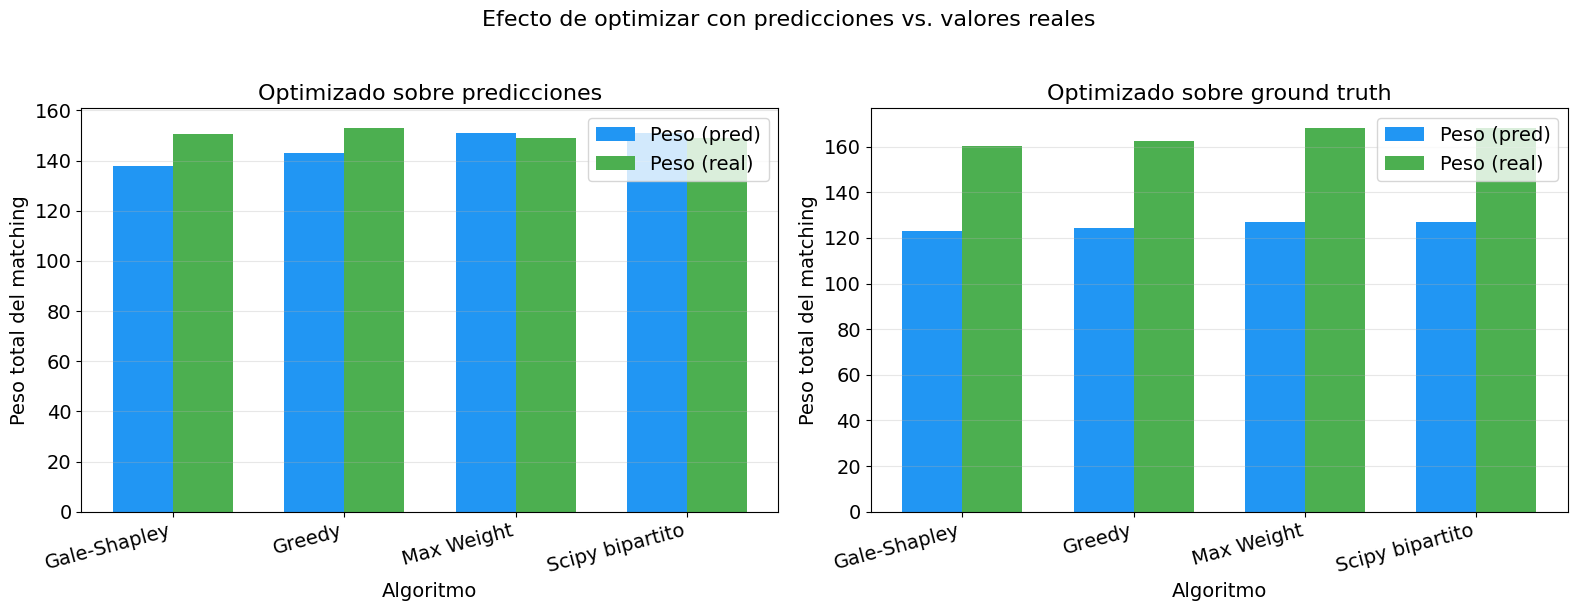

Guardado en img/pred_vs_real_comparison.svg


In [25]:
# Visualización: peso real obtenido por cada algoritmo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

algos = algo_names
w_pred_on_pred = [eval_matching(m, P_mut_est, P_mut)[0] for m in matchings_pred]
w_real_on_pred = [eval_matching(m, P_mut_est, P_mut)[1] for m in matchings_pred]
w_pred_on_real = [eval_matching(m, P_mut_est, P_mut)[0] for m in matchings_real]
w_real_on_real = [eval_matching(m, P_mut_est, P_mut)[1] for m in matchings_real]

x = np.arange(len(algos))
width = 0.35

# Panel izquierdo: matching optimizado sobre predicciones
bars1 = ax1.bar(x - width/2, w_pred_on_pred, width, label="Peso (pred)", color="#2196F3")
bars2 = ax1.bar(x + width/2, w_real_on_pred, width, label="Peso (real)", color="#4CAF50")
ax1.set_xlabel("Algoritmo")
ax1.set_ylabel("Peso total del matching")
ax1.set_title("Optimizado sobre predicciones")
ax1.set_xticks(x)
ax1.set_xticklabels(algos, rotation=15, ha="right")
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# Panel derecho: matching optimizado sobre ground truth
bars3 = ax2.bar(x - width/2, w_pred_on_real, width, label="Peso (pred)", color="#2196F3")
bars4 = ax2.bar(x + width/2, w_real_on_real, width, label="Peso (real)", color="#4CAF50")
ax2.set_xlabel("Algoritmo")
ax2.set_ylabel("Peso total del matching")
ax2.set_title("Optimizado sobre ground truth")
ax2.set_xticks(x)
ax2.set_xticklabels(algos, rotation=15, ha="right")
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

fig.suptitle("Efecto de optimizar con predicciones vs. valores reales", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(IMG_DIR / "pred_vs_real_comparison.svg", bbox_inches="tight")
plt.show()
print("Guardado en img/pred_vs_real_comparison.svg")

In [26]:
# Cual algoritmo sufre mas por usar predicciones en lugar de ground truth?
print("Perdida de valor real por usar predicciones en lugar de ground truth:\n")
for name, m_pred, m_real in zip(algo_names, matchings_pred, matchings_real):
    _, w_real_pred = eval_matching(m_pred, P_mut_est, P_mut)
    _, w_real_real = eval_matching(m_real, P_mut_est, P_mut)
    loss = (1 - w_real_pred / w_real_real) * 100
    print(f"  {name:20s}: optimizar con predicciones pierde {loss:+.1f}% de valor real")

print("\nUn algoritmo mas ambicioso (que busca el optimo global) puede sufrir mas")
print("cuando las predicciones son imperfectas, porque confia mas en los pesos exactos.")

Perdida de valor real por usar predicciones en lugar de ground truth:

  Gale-Shapley        : optimizar con predicciones pierde +6.0% de valor real
  Greedy              : optimizar con predicciones pierde +5.6% de valor real
  Max Weight          : optimizar con predicciones pierde +11.6% de valor real
  Scipy bipartito     : optimizar con predicciones pierde +11.6% de valor real

Un algoritmo mas ambicioso (que busca el optimo global) puede sufrir mas
cuando las predicciones son imperfectas, porque confia mas en los pesos exactos.


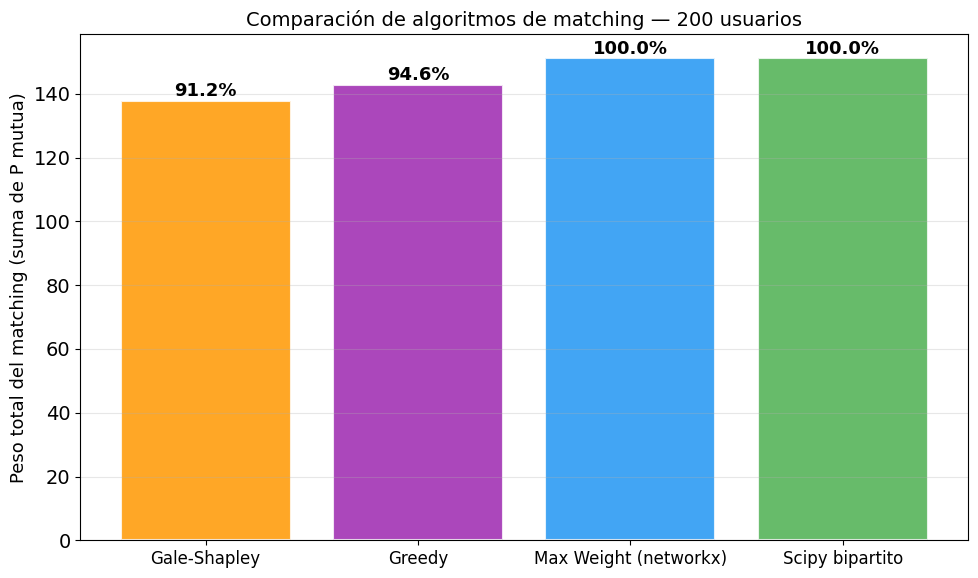

Guardado: img/matching_bar_chart.svg


In [27]:
# Gráfico de barras: comparación de algoritmos (200 usuarios) — para slides
fig, ax = plt.subplots(figsize=(10, 6))

algo_labels = results["Algoritmo"].tolist()
weights = results["Peso total"].tolist()
pcts = results["% del óptimo (bipartito)"].tolist()

colors = ["#FF9800", "#9C27B0", "#2196F3", "#4CAF50"]
bars = ax.bar(algo_labels, weights, color=colors, alpha=0.85, edgecolor="white", linewidth=1.5)

# Anotar % del óptimo
for bar, pct in zip(bars, pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=13, fontweight="bold",
    )

ax.set_ylabel("Peso total del matching (suma de P mutua)", fontsize=13)
ax.set_title("Comparación de algoritmos de matching — 200 usuarios", fontsize=14)
ax.tick_params(axis="x", labelsize=12)
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(IMG_DIR / "matching_bar_chart.svg", bbox_inches="tight")
plt.show()
print("Guardado: img/matching_bar_chart.svg")

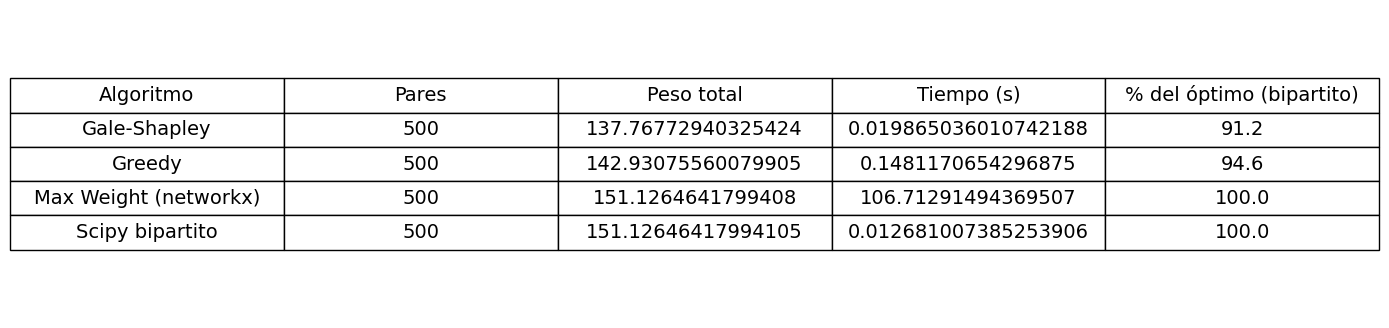

Guardado: img/matching_results_table.svg


In [28]:
# Guardar tabla comparativa (200 usuarios) como imagen para slides
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis("off")
table = ax.table(
    cellText=results.values,
    colLabels=results.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 1.8)
fig.tight_layout()
fig.savefig(IMG_DIR / "matching_results_table.svg", bbox_inches="tight")
plt.show()
print("Guardado: img/matching_results_table.svg")